# Voting Classifiers

The idea behind voting classifiers is as follows:
1. You train a few different models. For example, an SVM, Logistic Regression, Random Forest, and K-Nearest Neighbors classifiers. 
2. When it comes time for prediction, you feed all the models the same sample.
3. You investigate the output of all the models and pick the most frequently output class as the final output of the voting. 

This approach is called a _hard voting_ classifier. 

Surprisingly, the voting classifier often achieves higher accuracy than the strongest classifier in the ensemble. Even if each classifier is a weak learner (it only performs slightly better than random guessing), then if you have a sufficient number of them, and they are sufficiently diverse, then you can still get a strong classifier by combining the weak classifiers together!

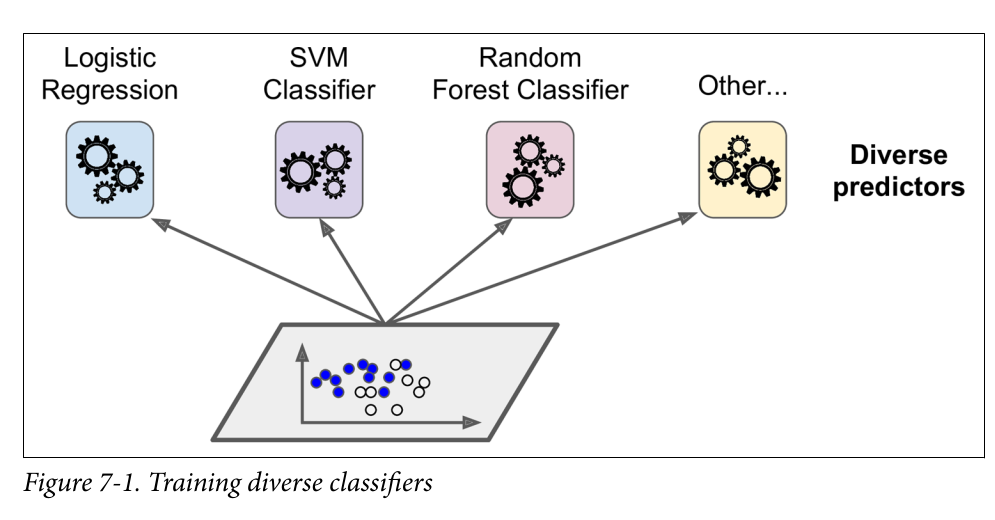
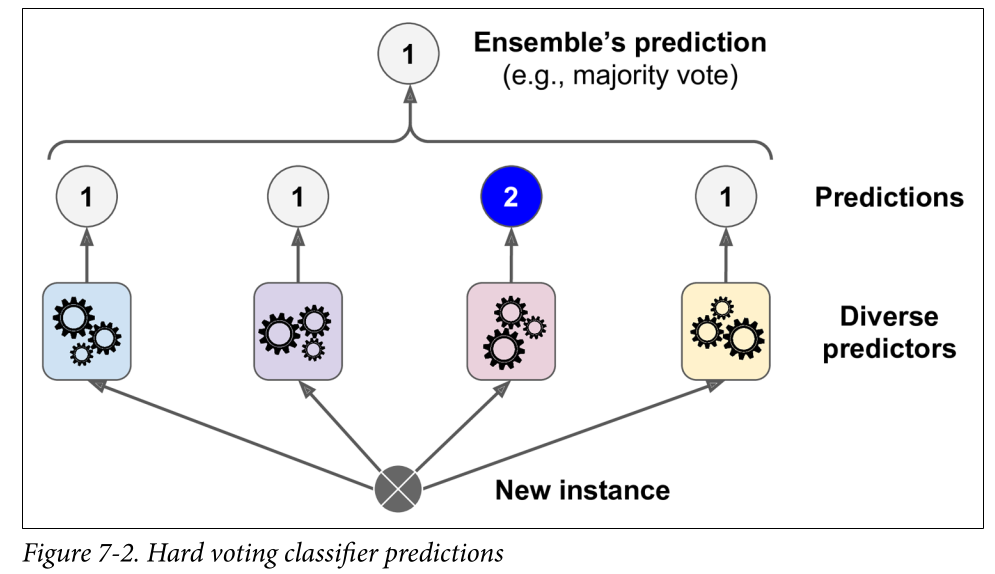

The reason why this works is best explained using the following analogy:
Image you have a coin that has a 51% chance of giving you heads, and a 49% chance of giving tails. If you toss this coin over and over again, the percentage of heads you get will slowly approach 51%, because with thousands of tosses, you essentially eliminate initial randomness. This means that the probability of getting a majority of heads increases the more you toss the coin. 

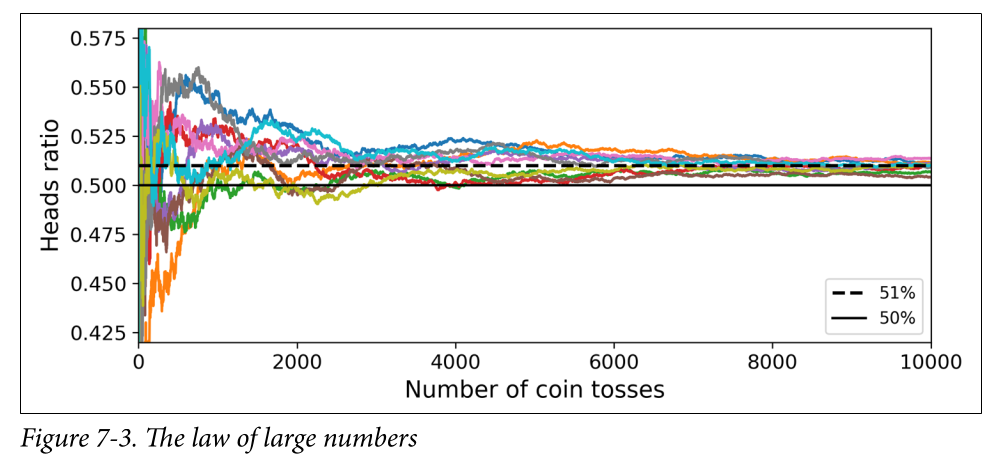

As you can see in the figure, as we toss the coins more and more times, the ratio of heads slowly approaches the true underlying probability of the coin of 51%. 

Similarly, if you have many classifiers with a probability of getting the right answer of 51% (barely better than random guessing), you can expect that using more and more classifiers will guarantee that the majority of them predict the answer correctly. However, for this approach to work, the classifiers need to make errors independantly from each other, but this cannot be the case since all the classifier are trained on the same data, which means that they tend to make the same errors. 

The solution to this problem is to train diverse classifiers that use completely different training algorithms to increase the chance that they make different errors from each other.

In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
X, y = make_moons(n_samples = 1000, noise = 0.3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [80]:
log_clf = LogisticRegression()
rnd_clf = RandomForestClassifier()
svm_clf = SVC(probability = True)
knn_clf = KNeighborsClassifier()

voting_clf = VotingClassifier(estimators = [
    ('lr', log_clf), ('rf', rnd_clf), ('svc', svm_clf), ('knn', knn_clf)
], voting = 'soft') #voting can be either "hard" or "soft"


In [81]:
from sklearn.metrics import accuracy_score

for clf in (log_clf, rnd_clf, svm_clf, knn_clf, voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))

LogisticRegression 0.83
RandomForestClassifier 0.86
SVC 0.89
KNeighborsClassifier 0.89
VotingClassifier 0.89


In this case, the voting classifier didn't get a better result than the best classifier, but sometimes it does get a better result depending on the dataset and the number of classifiers used in the voting process!

__Notes:__ 
1. You can use "soft" instead of "hard" voting. The difference is that soft voting calculates the average of the probabilities output by each classifier, and selects the class with the highest overall probability to be the output. However, for this method to work, all the classifiers need to be able to output a probability, which isn't the default for the SVM, so you need to set the probability = True in the SVM constructor to make it output probabilities.
2. Soft voting is often better than hard voting because it gives more weight to confident votes.